In [1]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.
import kagglehub
apoorvwatsky_bank_transaction_data_path = kagglehub.dataset_download('apoorvwatsky/bank-transaction-data')

print('Data source import complete.')


Data source import complete.


In [2]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt
import seaborn as sns
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All"
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/apoorvwatsky/bank-transaction-data/bank.xlsx


In [3]:
# Install dependencies as needed:
# pip install kagglehub[pandas-datasets]
import kagglehub
from kagglehub import KaggleDatasetAdapter

# Set the path to the file you'd like to load
file_path = "bank.xlsx"

# Load the latest version
df = kagglehub.load_dataset(
  KaggleDatasetAdapter.PANDAS,
  "apoorvwatsky/bank-transaction-data",
  file_path,
  # Provide any additional arguments like
  # sql_query or pandas_kwargs. See the
  # documenation for more information:
  # https://github.com/Kaggle/kagglehub/blob/main/README.md#kaggledatasetadapterpandas
)

display("First 5 records:", df.head())

/tmp/ipykernel_55/2076471949.py:10: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df = kagglehub.load_dataset(


'First 5 records:'

,Account No,DATE,TRANSACTION DETAILS,CHQ.NO.,VALUE DATE,WITHDRAWAL AMT,DEPOSIT AMT,BALANCE AMT,.
0,409000611074',2017-06-29,TRF FROM Indiaforensic SERVICES,NaN,2017-06-29,NaN,1000000.0,1000000.0,.
1,409000611074',2017-07-05,TRF FROM Indiaforensic SERVICES,NaN,2017-07-05,NaN,1000000.0,2000000.0,.
2,409000611074',2017-07-18,FDRL/INTERNAL FUND TRANSFE,NaN,2017-07-18,NaN,500000.0,2500000.0,.
3,409000611074',2017-08-01,TRF FRM Indiaforensic SERVICES,NaN,2017-08-01,NaN,3000000.0,5500000.0,.
4,409000611074',2017-08-16,FDRL/INTERNAL FUND TRANSFE,NaN,2017-08-16,NaN,500000.0,6000000.0,.


In [4]:
def dataDiscribtion(df):
    data = df.copy()
    print("\nData wise columns : ",data.columns)

    print("\nFinding the null values : \n",data.isnull().sum())

    print("\nColumn vise unique values : ")
    for i in df.columns:
        print(f"\n{i} unique values : ",df[i].nunique())
dataDiscribtion(df)


Data wise columns :  Index(['Account No', 'DATE', 'TRANSACTION DETAILS', 'CHQ.NO.', 'VALUE DATE',
       'WITHDRAWAL AMT', 'DEPOSIT AMT', 'BALANCE AMT', '.'],
      dtype='object')

Finding the null values : 
 Account No                  0
DATE                        0
TRANSACTION DETAILS      2499
CHQ.NO.                115296
VALUE DATE                  0
WITHDRAWAL AMT          62652
DEPOSIT AMT             53549
BALANCE AMT                 0
.                           0
dtype: int64

Column vise unique values : 

Account No unique values :  10

DATE unique values :  1294

TRANSACTION DETAILS unique values :  44806

CHQ.NO. unique values :  894

VALUE DATE unique values :  1294

WITHDRAWAL AMT unique values :  20881

DEPOSIT AMT unique values :  20145

BALANCE AMT unique values :  115171

. unique values :  1


In [5]:
import pandas as pd

def dataCleaning(df):
    data = df.copy()

    # Drop columns
    cols_to_drop = ['.', 'CHQ.NO.']
    data = data.drop(columns=[c for c in cols_to_drop if c in data.columns], errors='ignore')

    # Fill nulls
    data['WITHDRAWAL AMT'] = data['WITHDRAWAL AMT'].fillna(0)
    data['DEPOSIT AMT'] = data['DEPOSIT AMT'].fillna(0)

    # Convert to datetime
    data['DATE'] = pd.to_datetime(data['DATE'], errors='coerce')
    data['VALUE DATE'] = pd.to_datetime(data['VALUE DATE'], errors='coerce')

    # Sort before aggregation (IMPORTANT)
    data = data.sort_values(['Account No', 'DATE'])

    # Create net flow at transaction level
    data['net_flow'] = data['DEPOSIT AMT'] - data['WITHDRAWAL AMT']

    daily_df = (
        data.groupby(['Account No', 'DATE'], as_index=False)
        .agg({
            'WITHDRAWAL AMT': 'sum',
            'DEPOSIT AMT': 'sum',
            'net_flow': 'sum',
            'BALANCE AMT': 'last',
            'TRANSACTION DETAILS':'count'
        })
    )

    # Rename txn count
    daily_df.rename(columns={
        'TRANSACTION DETAILS': 'txn_count'
    }, inplace=True)

    # Sort final output
    daily_df = daily_df.sort_values(['Account No', 'DATE']).reset_index(drop=True)

    return daily_df


cleandata = dataCleaning(df)
display(cleandata)

,Account No,DATE,WITHDRAWAL AMT,DEPOSIT AMT,net_flow,BALANCE AMT,txn_count
0,1196428',2015-01-01,0.00,2000000.0,2000000.00,-1.584916e+09,2
1,1196428',2015-01-02,5500056.18,2462620.0,-3037436.18,-1.587953e+09,9
2,1196428',2015-01-03,2200000.00,2948160.0,748160.00,-1.587205e+09,4
3,1196428',2015-01-05,3231000.00,3877320.0,646320.00,-1.586559e+09,5
4,1196428',2015-01-06,3880056.18,3650750.0,-229306.18,-1.586788e+09,6
...,...,...,...,...,...,...,...
6213,409000611074',2019-01-29,301645.00,300000.0,-1645.00,1.525434e+06,3
6214,409000611074',2019-01-30,404412.00,0.0,-404412.00,1.121022e+06,2
6215,409000611074',2019-01-31,225251.00,300000.0,74749.00,1.195771e+06,3
6216,409000611074',2019-02-01,133571.00,0.0,-133571.00,1.062200e+06,2


In [6]:
def calculate_slope(series):
    y = series.values
    x = np.arange(len(y))
    if len(y) < 2:
        return np.nan
    slope = np.polyfit(x, y, 1)[0]
    return slope

In [7]:
def featureCreation(df):
    data = df.copy()

    data = data.sort_values(['Account No', 'DATE'])

    data['net_flow'] = (
        data['DEPOSIT AMT'] - data['WITHDRAWAL AMT']
    )

    data['days_since_last_txn'] = (
        data.groupby('Account No')['DATE']
        .diff()
        .dt.days
    )

    data['rolling_txn_7d'] = (
        data.groupby('Account No')['txn_count']
        .rolling(7)
        .sum()
        .reset_index(level=0, drop=True)
    )

    data['rolling_dep_30d'] = (
        data.groupby('Account No')['DEPOSIT AMT']
        .rolling(30)
        .sum()
        .reset_index(level=0, drop=True)
    )

    data['rolling_wdr_30d'] = (
        data.groupby('Account No')['WITHDRAWAL AMT']
        .rolling(30)
        .sum()
        .reset_index(level=0, drop=True)
    )

    data['rolling_net_30d'] = (
        data.groupby('Account No')['net_flow']
        .rolling(30)
        .sum()
        .reset_index(level=0, drop=True)
    )

    data['balance_std_30d'] = (
        data.groupby('Account No')['BALANCE AMT']
        .rolling(30)
        .std()
        .reset_index(level=0, drop=True)
    )

    data['txn_std_30d'] = (
        data.groupby('Account No')['net_flow']
        .rolling(30)
        .std()
        .reset_index(level=0, drop=True)
    )

    data['balance_ma_7d'] = (
        data.groupby('Account No')['BALANCE AMT']
        .rolling(7)
        .mean()
        .reset_index(level=0, drop=True)
    )

    data['wd_to_dep_ratio_30d'] = (
        data['rolling_wdr_30d'] /
        (data['rolling_dep_30d'] + 1)
    )

    data['day_of_week'] = data['DATE'].dt.dayofweek
    data['month'] = data['DATE'].dt.month

    data["balance_slope_30d"] = (
        data.groupby("Account No")["BALANCE AMT"]
        .rolling(window=30)
        .apply(calculate_slope, raw=False)
        .reset_index(level=0, drop=True)
    )

    data["withdrawal_acceleration_30d"] = (
        data.groupby("Account No")["rolling_wdr_30d"]
        .diff(7)
    )

    data["deposit_acceleration_30d"] = (
        data.groupby("Account No")["rolling_dep_30d"]
        .diff(7)
    )

    data["txn_acceleration_7d"] = (
        data.groupby("Account No")["rolling_txn_7d"]
        .diff(3)
    )

    data["cash_buffer_ratio"] = (
        data["balance_ma_7d"] /
        (data["rolling_wdr_30d"] + 1e-6)
    )

    data["flow_volatility_ratio"] = (
        data["balance_std_30d"] /
        (data["balance_ma_7d"] + 1e-6)
    )

    data["deposit_std_30d"] = (
        data.groupby("Account No")["DEPOSIT AMT"]
        .rolling(window=30)
        .std()
        .reset_index(level=0, drop=True)
    )

    data["deposit_consistency"] = (
        data["rolling_dep_30d"] /
        (data["deposit_std_30d"] + 1e-6)
    )

    data["future_withdrawal_7d"] = (
        data.groupby("Account No")["WITHDRAWAL AMT"]
        .shift(-1)
        .rolling(7)
        .sum()
    )

    data["future_deposit_30d"] = (
        data.groupby("Account No")["DEPOSIT AMT"]
        .shift(-1)
        .rolling(30)
        .sum()
    )

    data["min_balance_next_30d"] = (
        data.groupby("Account No")["BALANCE AMT"]
        .shift(-1)
        .rolling(30)
        .min()
    )

    data["overdraft_30d_label"] = (
        data["min_balance_next_30d"] < 0
    ).astype(int)

    # Withdrawal Spike Score
    data["withdrawal_spike_score"] = (
        (data["WITHDRAWAL AMT"] - (data["rolling_wdr_30d"] / 30)) /
        ((data["rolling_wdr_30d"] / 30) + 1e-6)
    )

    # Deposit Spike Score
    data["deposit_spike_score"] = (
        (data["DEPOSIT AMT"] - (data["rolling_dep_30d"] / 30)) /
        ((data["rolling_dep_30d"] / 30) + 1e-6)
    )

    # Withdrawal Z-Score
    data["withdrawal_zscore_30d"] = (
        (data["WITHDRAWAL AMT"] - (data["rolling_wdr_30d"] / 30)) /
        (data["txn_std_30d"] + 1e-6)
    )

    # Deposit Z-Score
    data["deposit_zscore_30d"] = (
        (data["DEPOSIT AMT"] - (data["rolling_dep_30d"] / 30)) /
        (data["deposit_std_30d"] + 1e-6)
    )

    # Balance Drop Ratio
    data["balance_drop_ratio"] = (
        (data["BALANCE AMT"] - data["balance_ma_7d"]) /
        (data["balance_ma_7d"] + 1e-6)
    )

    # Withdrawal Pressure
    data["withdrawal_pressure"] = (
        data["rolling_wdr_30d"] /
        (data["balance_ma_7d"] + 1e-6)
    )

    # Negative Flow Ratio
    data["negative_flow_ratio"] = (
        data["rolling_net_30d"] /
        (data["balance_ma_7d"] + 1e-6)
    )

    # Stability Score
    data["stability_score"] = (
        1 /
        (data["balance_std_30d"] + data["txn_std_30d"] + 1e-6)
    )

    # Large Transaction Flag
    data["large_withdrawal_flag"] = (
        data["WITHDRAWAL AMT"] >
        (data["rolling_wdr_30d"] / 10)
    ).astype(int)

    data["large_deposit_flag"] = (
        data["DEPOSIT AMT"] >
        (data["rolling_dep_30d"] / 10)
    ).astype(int)

    data['has_overdraft'] = (data['overdraft_30d_label'] > 0).astype(int)

    data = data.dropna()

    return data
processed_df = featureCreation(cleandata)
display(processed_df.shape)
processed_df.columns

(5848, 41)

Index(['Account No', 'DATE', 'WITHDRAWAL AMT', 'DEPOSIT AMT', 'net_flow',
       'BALANCE AMT', 'txn_count', 'days_since_last_txn', 'rolling_txn_7d',
       'rolling_dep_30d', 'rolling_wdr_30d', 'rolling_net_30d',
       'balance_std_30d', 'txn_std_30d', 'balance_ma_7d',
       'wd_to_dep_ratio_30d', 'day_of_week', 'month', 'balance_slope_30d',
       'withdrawal_acceleration_30d', 'deposit_acceleration_30d',
       'txn_acceleration_7d', 'cash_buffer_ratio', 'flow_volatility_ratio',
       'deposit_std_30d', 'deposit_consistency', 'future_withdrawal_7d',
       'future_deposit_30d', 'min_balance_next_30d', 'overdraft_30d_label',
       'withdrawal_spike_score', 'deposit_spike_score',
       'withdrawal_zscore_30d', 'deposit_zscore_30d', 'balance_drop_ratio',
       'withdrawal_pressure', 'negative_flow_ratio', 'stability_score',
       'large_withdrawal_flag', 'large_deposit_flag', 'has_overdraft'],
      dtype='object')

In [8]:
predictive_cols = [
    "net_flow",
    "days_since_last_txn",
    "rolling_txn_7d",
    "rolling_dep_30d",
    "rolling_wdr_30d",
    "rolling_net_30d",
    "balance_std_30d",
    "txn_std_30d",
    "balance_ma_7d",
    "wd_to_dep_ratio_30d",
    "balance_slope_30d",
    "withdrawal_acceleration_30d",
    "deposit_acceleration_30d",
    "txn_acceleration_7d",
    "cash_buffer_ratio",
    "flow_volatility_ratio",
    "deposit_std_30d",
    "deposit_consistency",
    "stability_score"
]

for col in predictive_cols:
    processed_df[col] = (
        processed_df.groupby("Account No")[col]
        .shift(1)
    )



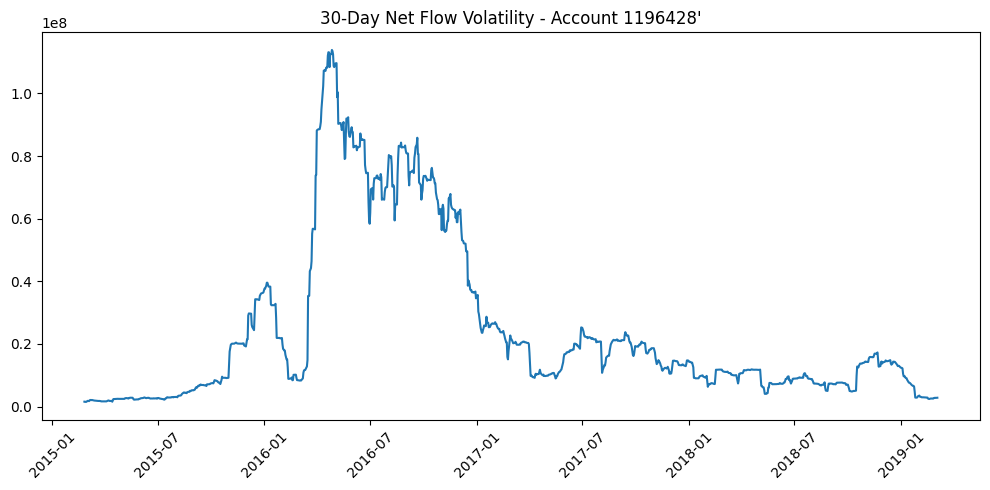

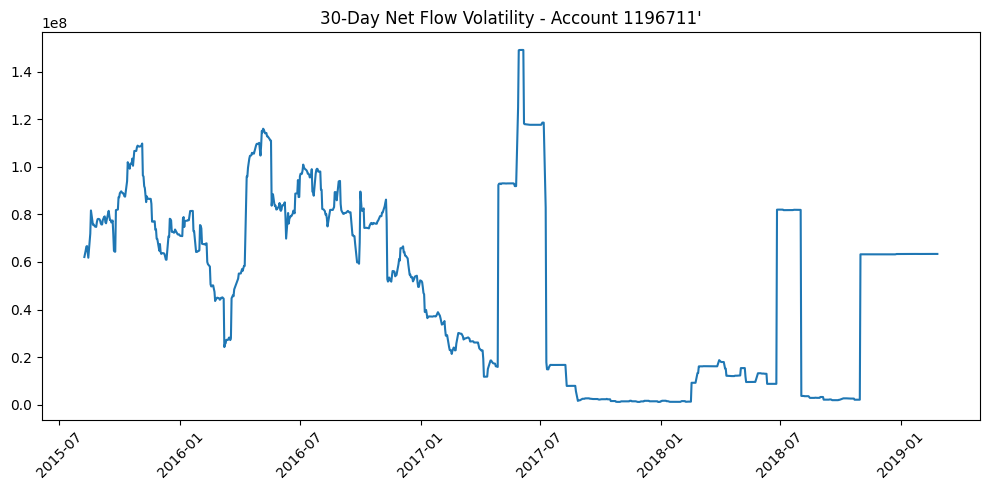

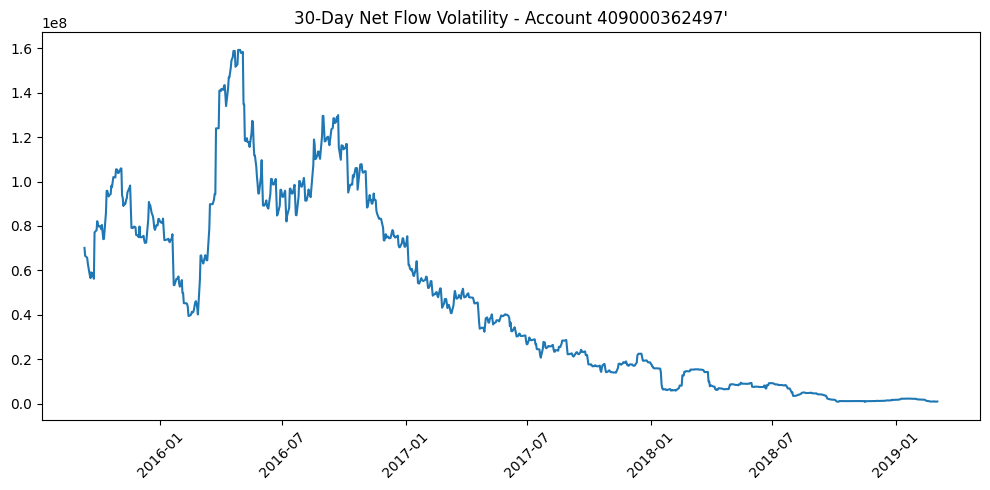

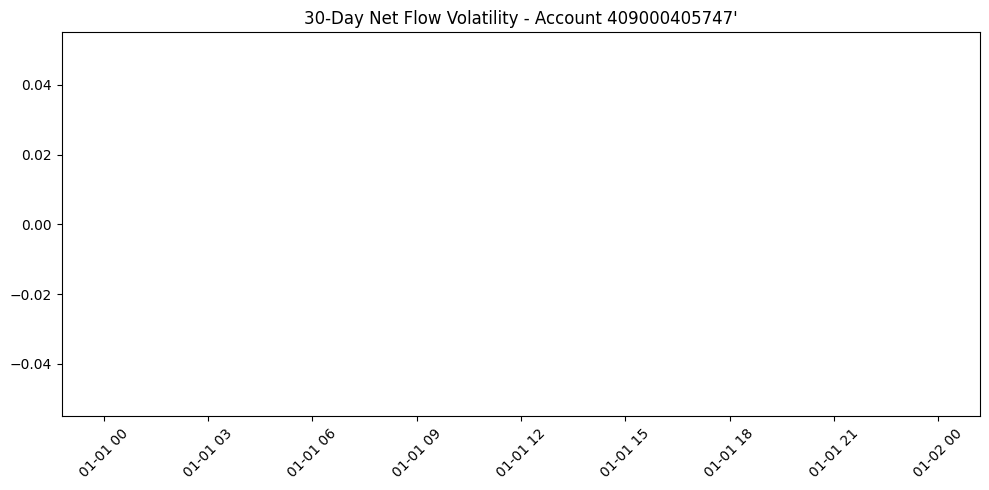

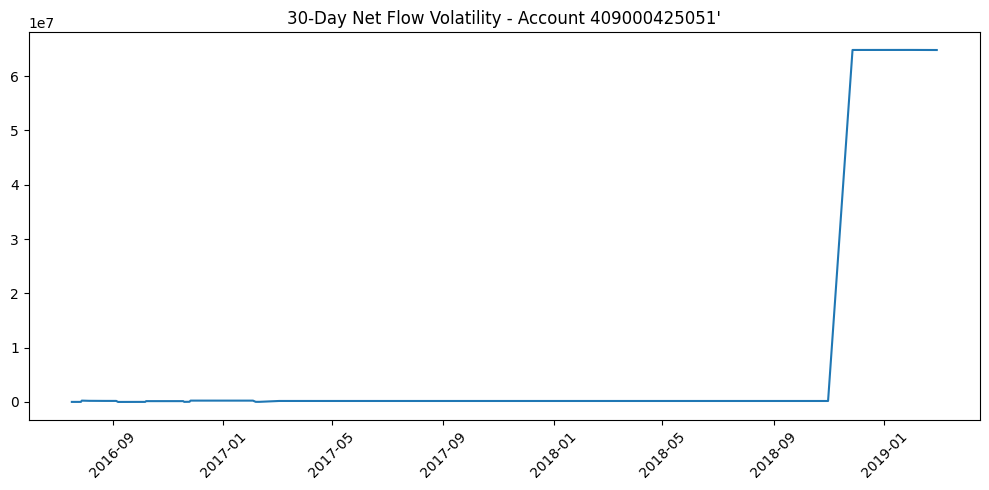

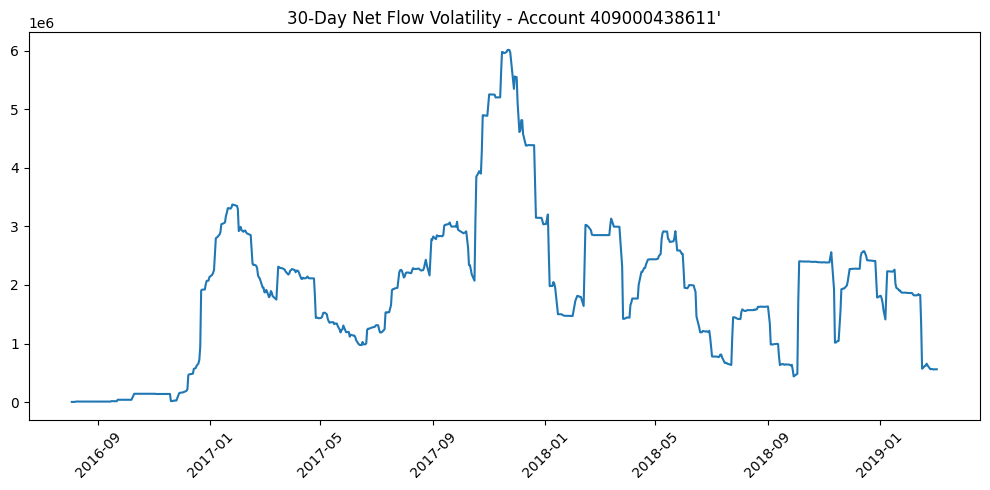

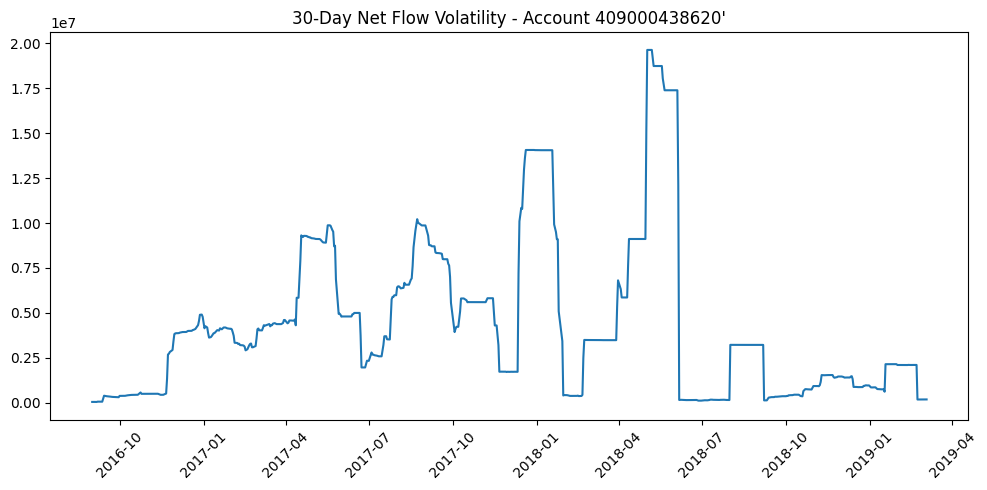

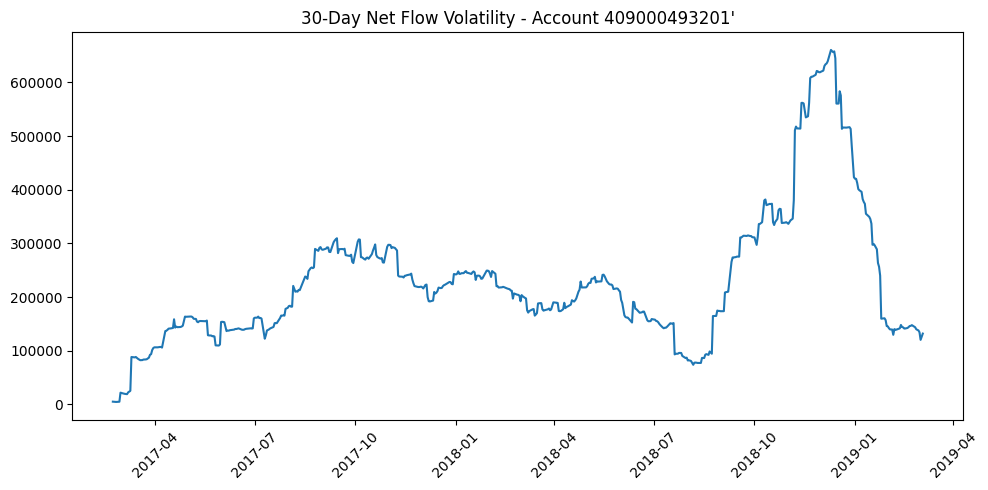

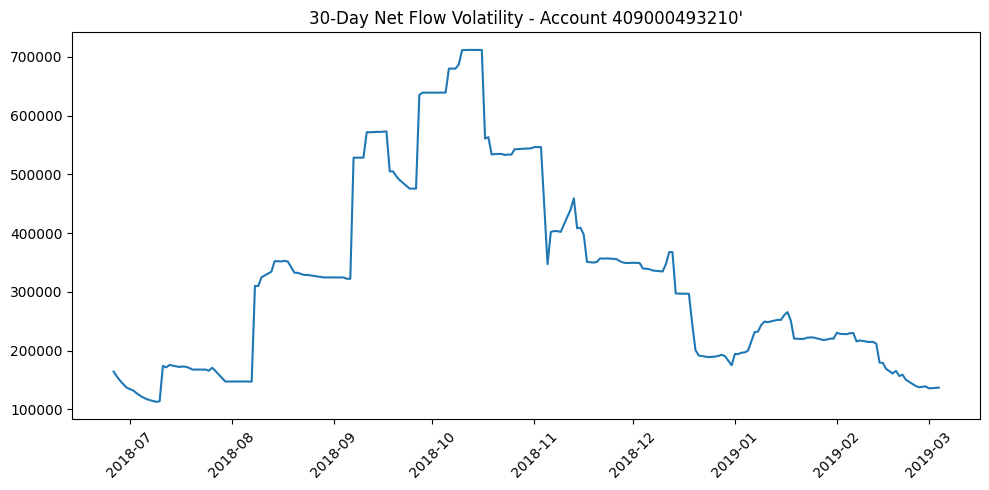

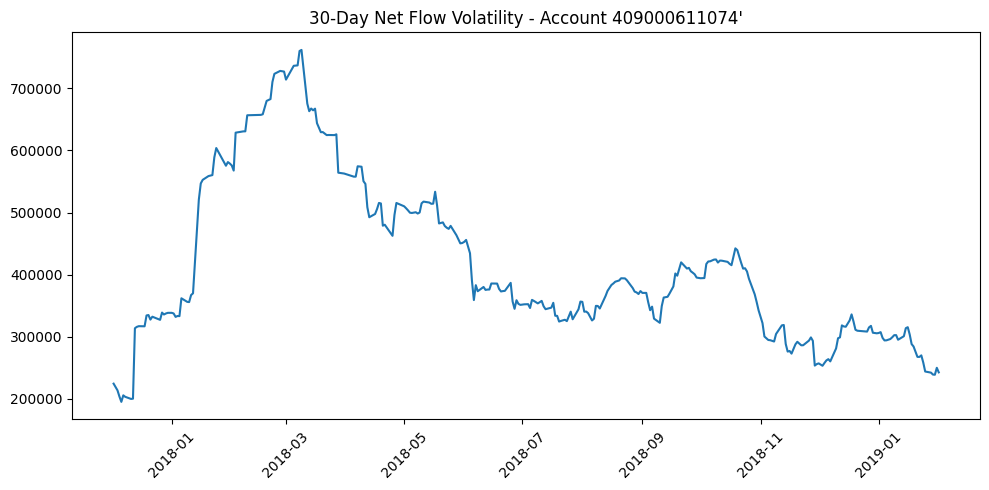

In [9]:
import matplotlib.pyplot as plt

def visualize_variance_accountwise(data):

    df = data.copy()
    df = df.sort_values(['Account No', 'DATE'])

    # Compute rolling std per account
    df['net_flow_std_30d'] = (
        df.groupby('Account No')['net_flow']
        .transform(lambda x: x.rolling(30, min_periods=10).std())
    )

    # Iterate account-wise
    for acc_no, acc_df in df.groupby('Account No'):

        plt.figure(figsize=(10,5))
        plt.plot(acc_df['DATE'], acc_df['net_flow_std_30d'])
        plt.title(f"30-Day Net Flow Volatility - Account {acc_no}")
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()
visualize_variance_accountwise(processed_df)

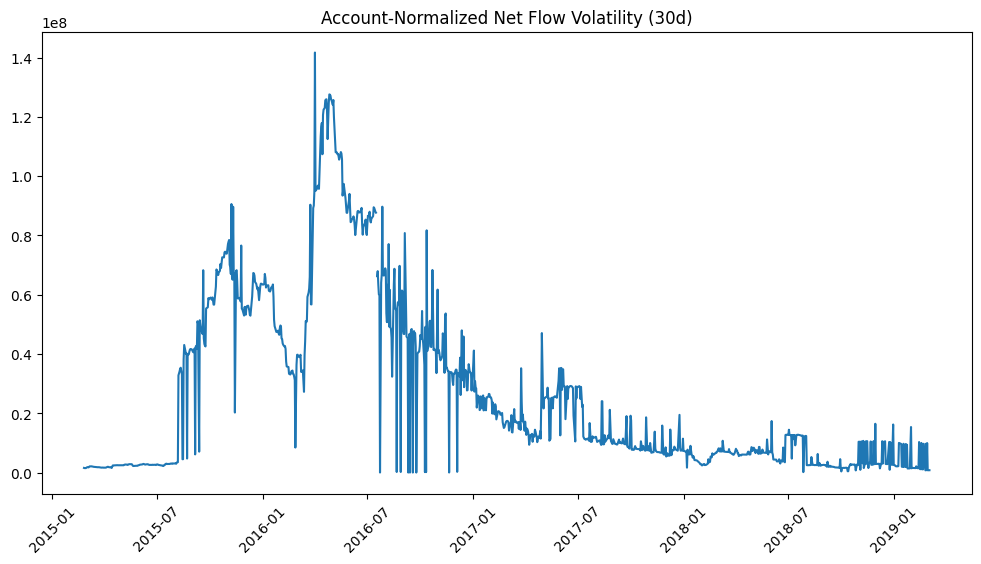

In [10]:
def visualize_variance_accountwise(data):

    df = data.copy()

    df['net_flow_std_30d'] = (
        df.groupby('Account No')['net_flow']
        .transform(lambda x: x.rolling(30, min_periods=10).std())
    )

    daily_avg = (
        df.groupby('DATE')['net_flow_std_30d']
        .mean()
        .reset_index()
    )

    plt.figure(figsize=(12,6))
    plt.plot(daily_avg['DATE'], daily_avg['net_flow_std_30d'])
    plt.title("Account-Normalized Net Flow Volatility (30d)")
    plt.xticks(rotation=45)
    plt.show()

visualize_variance_accountwise(processed_df)

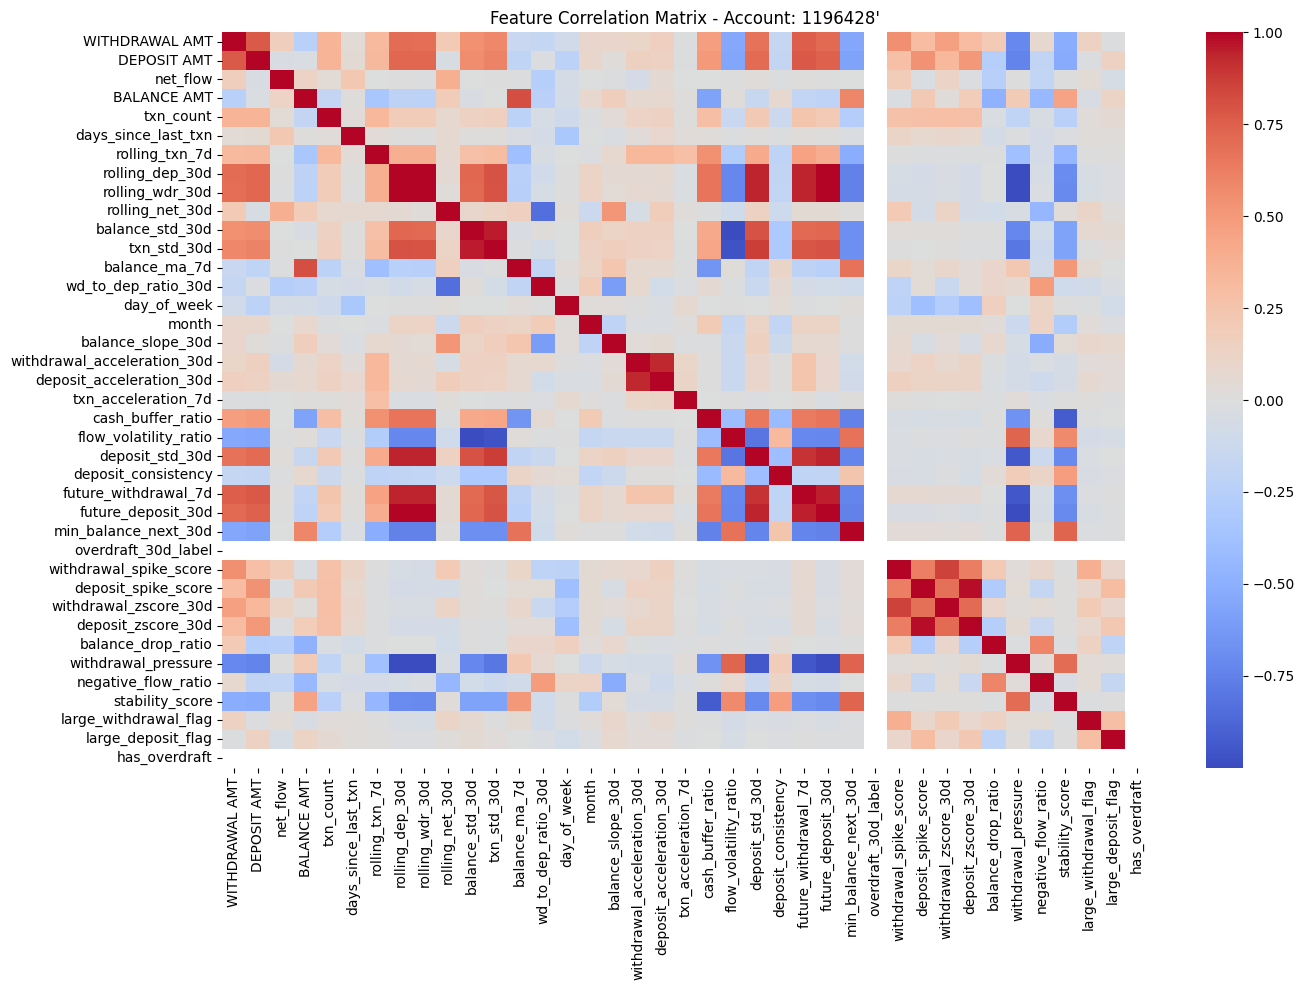

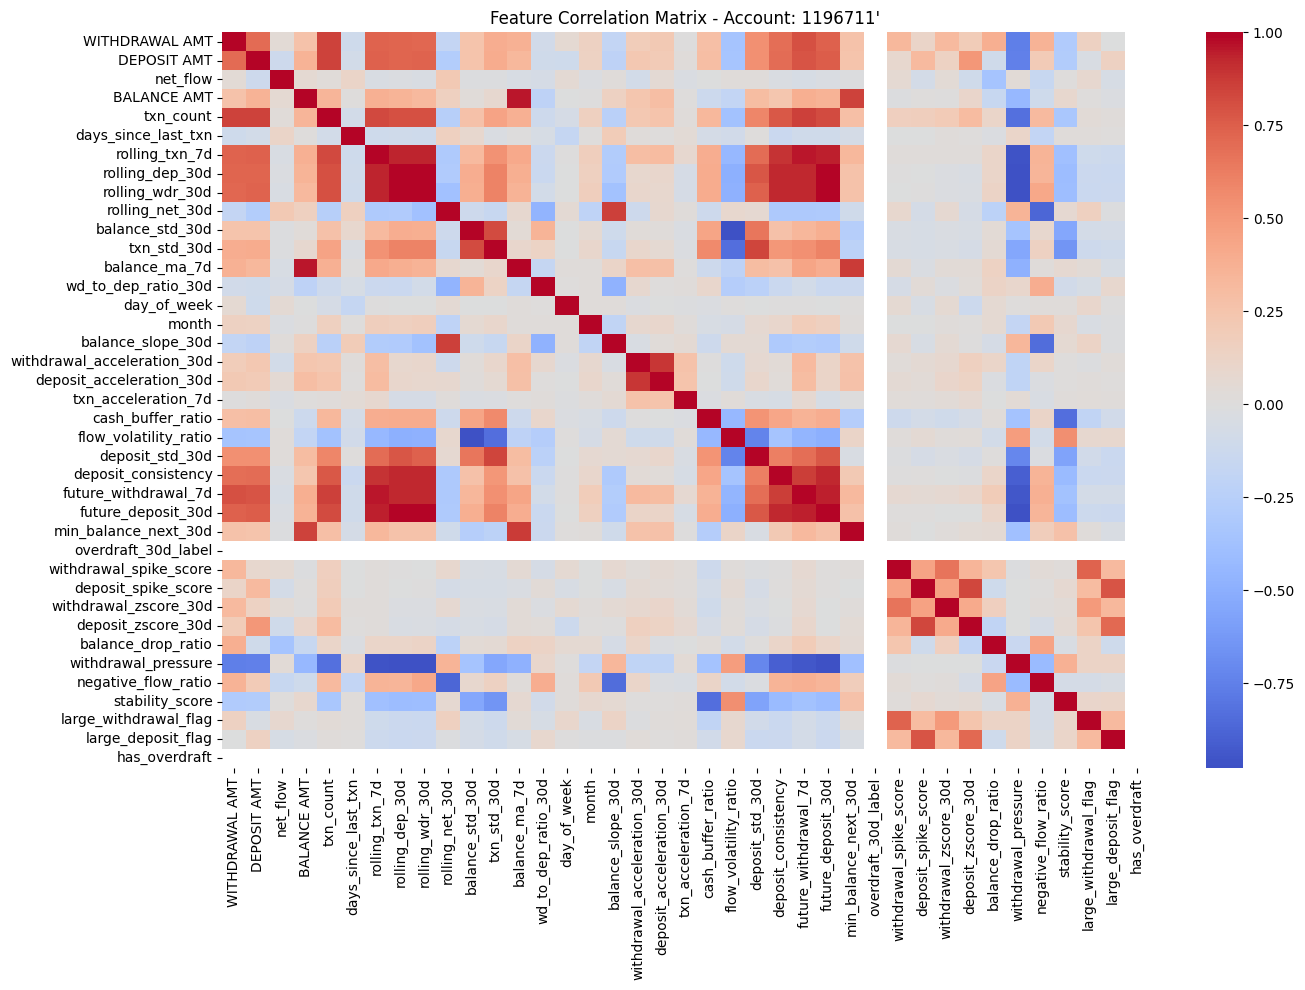

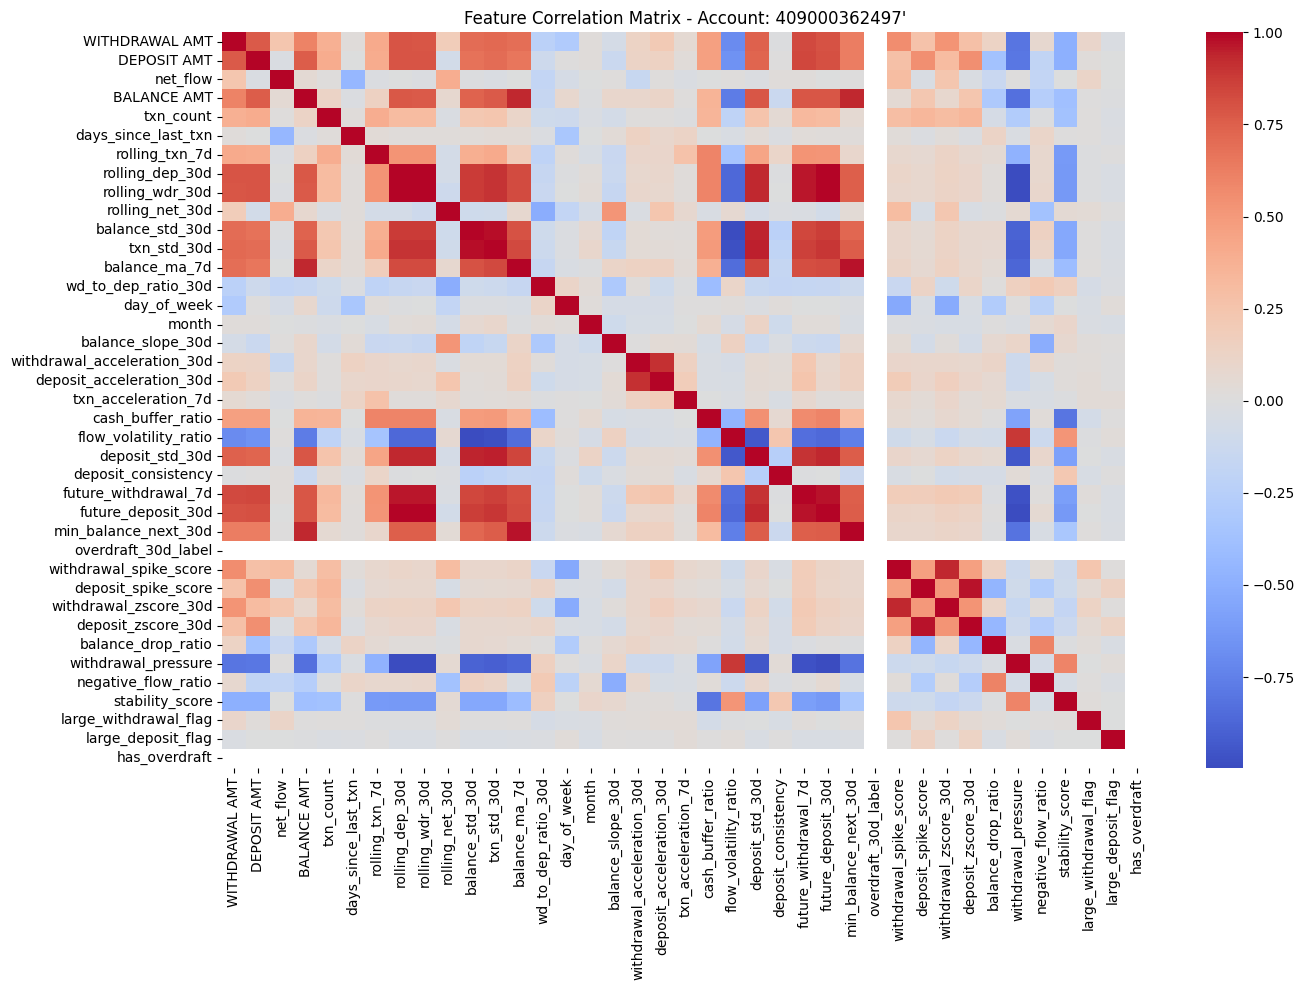

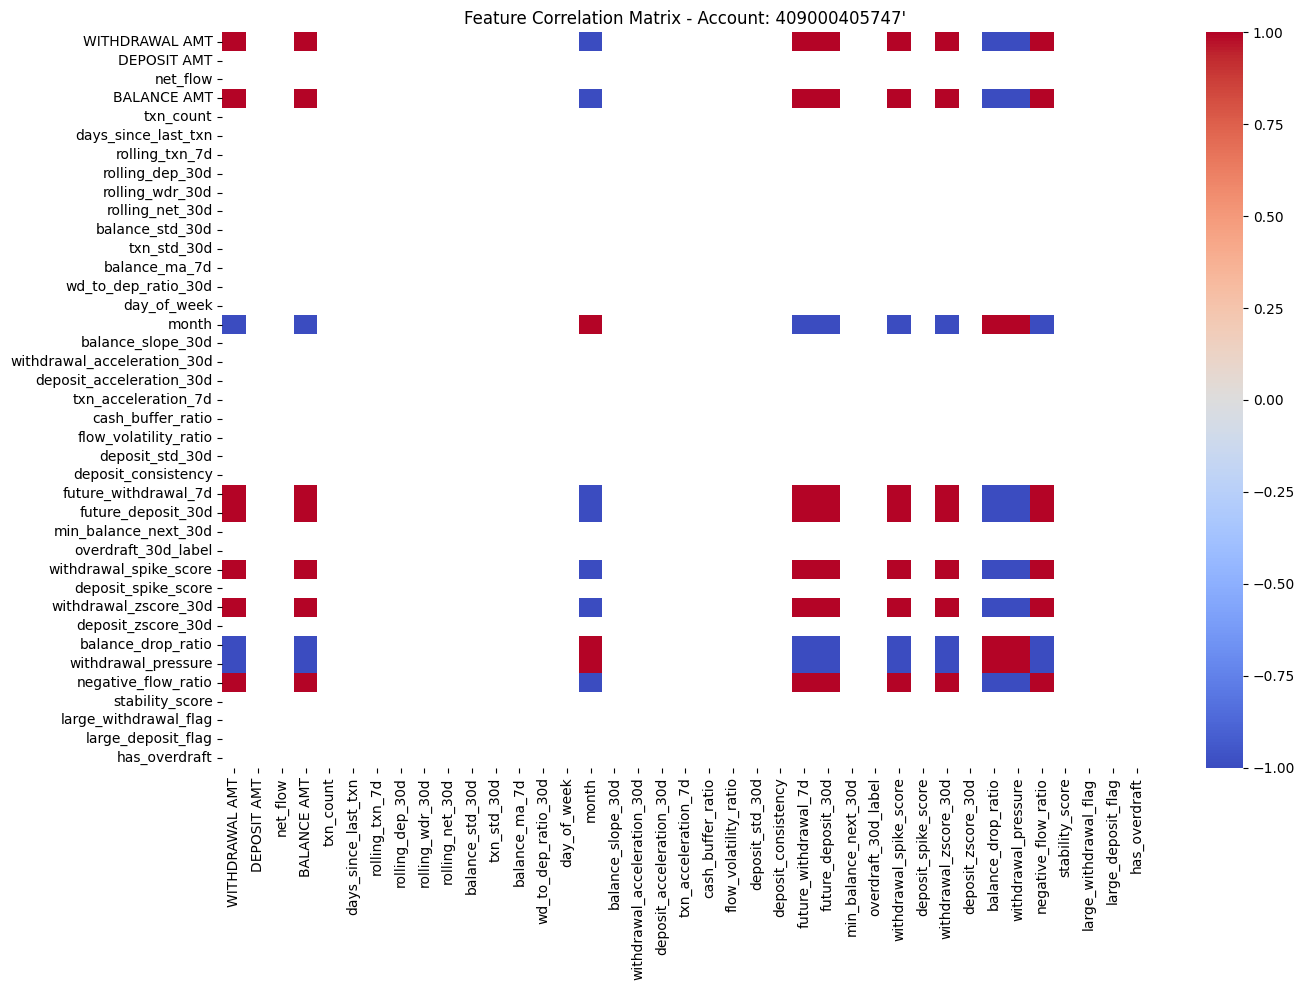

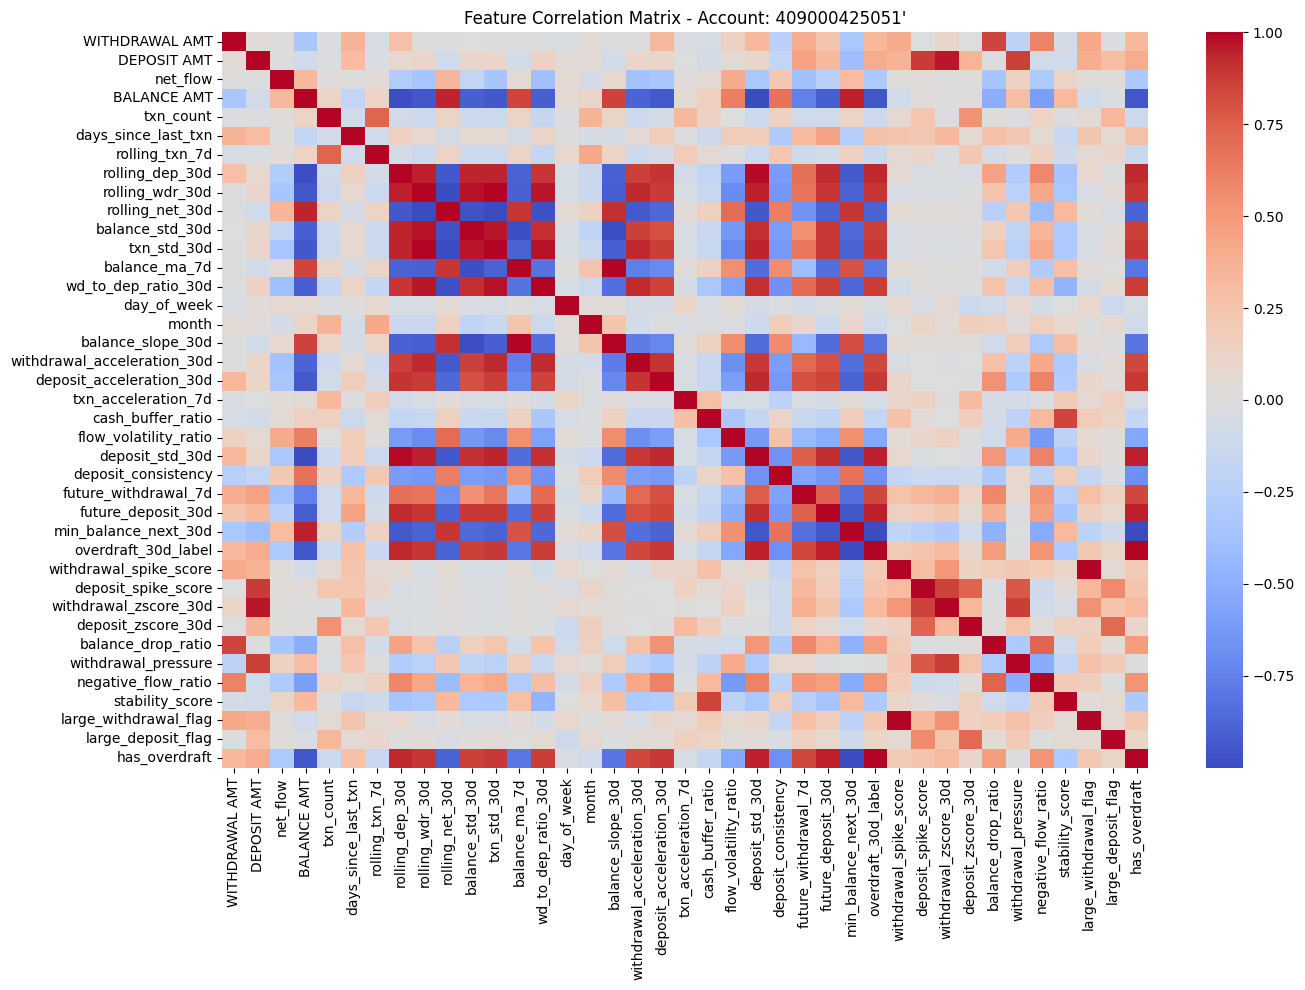

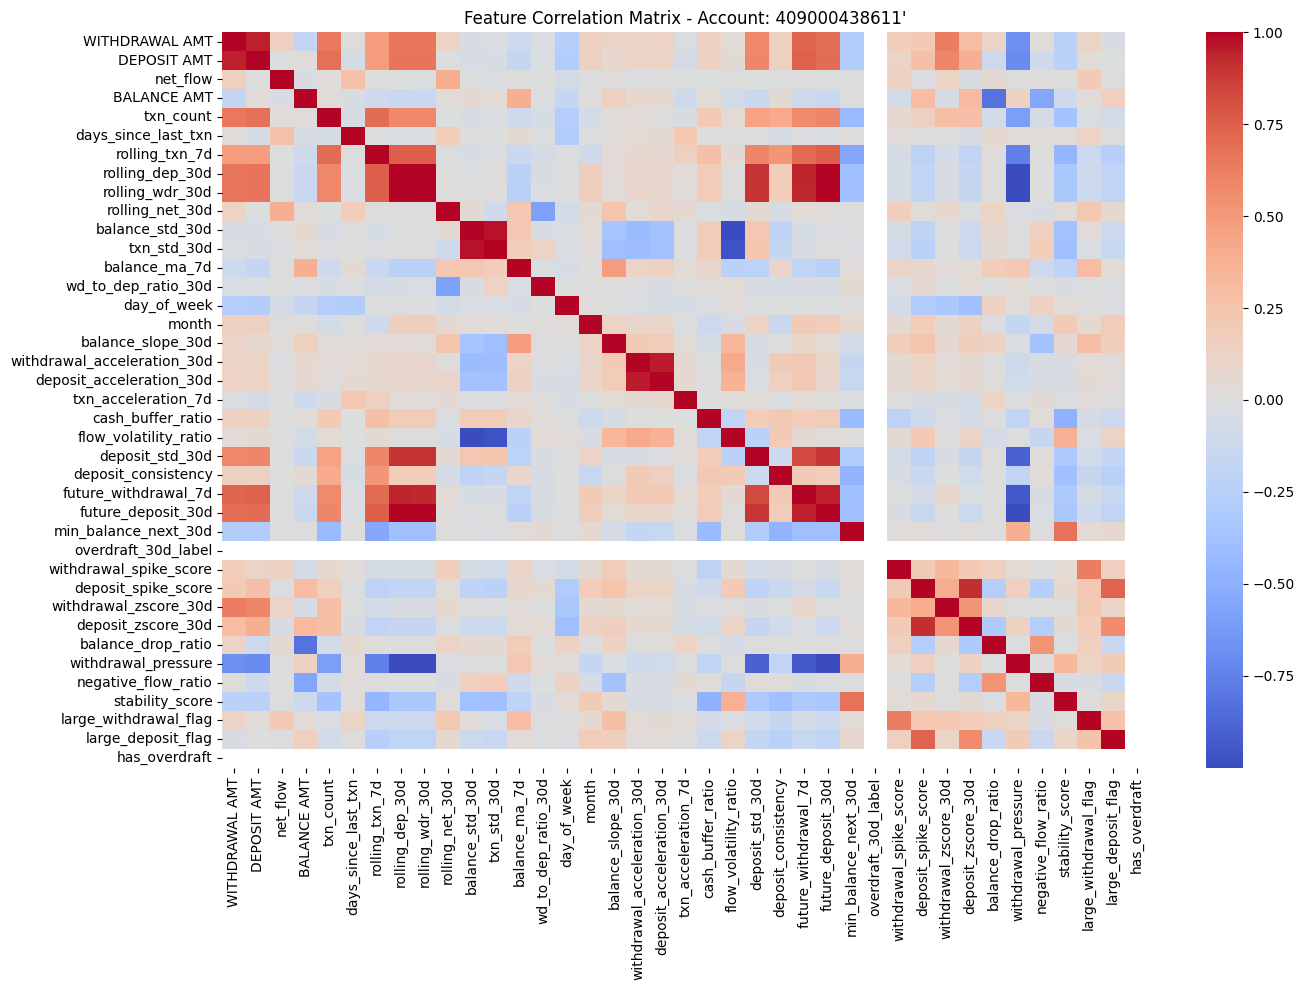

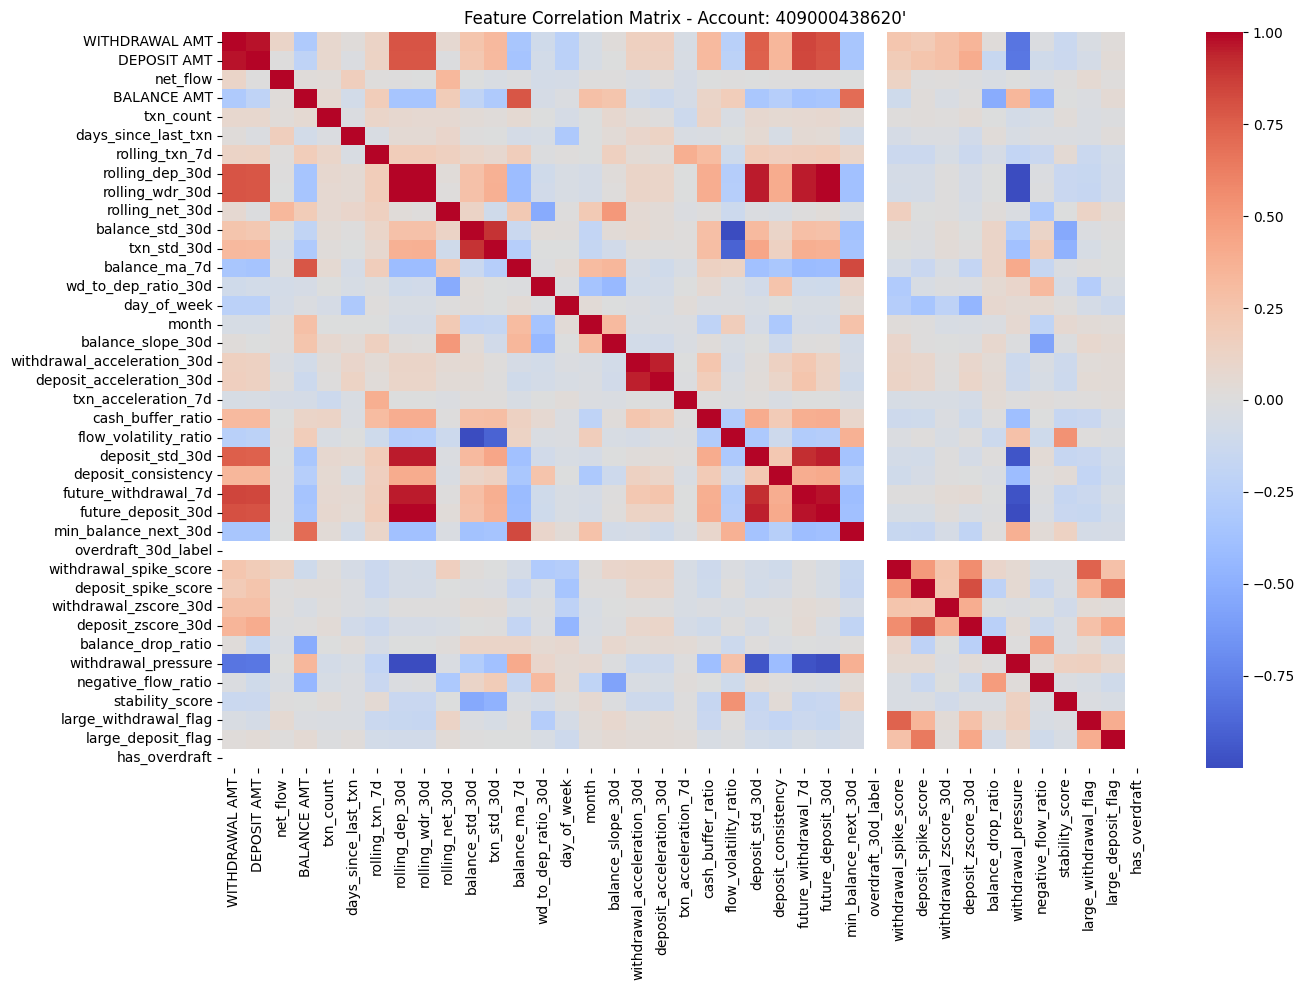

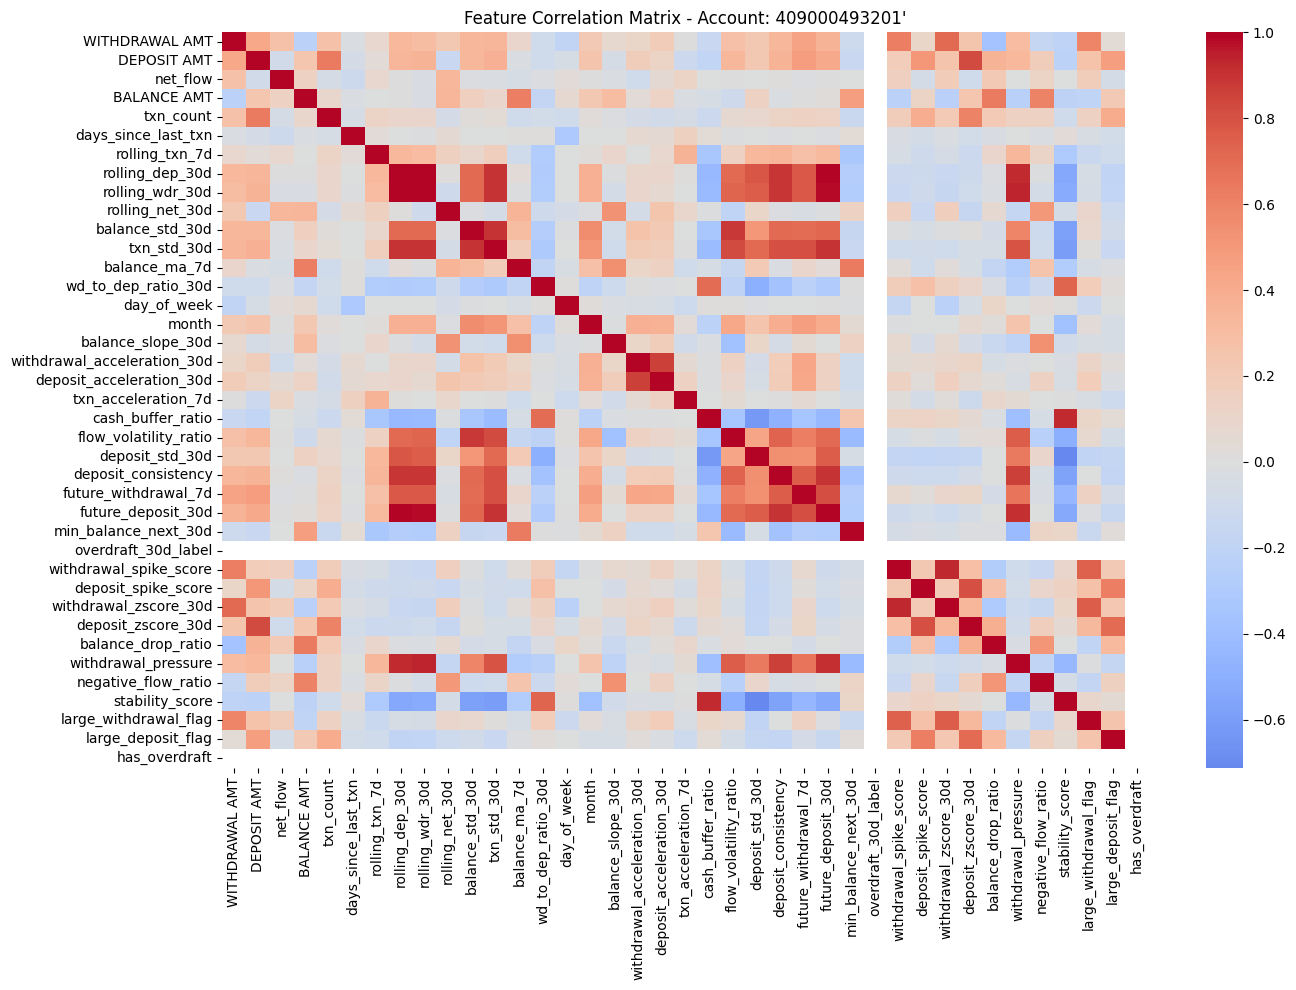

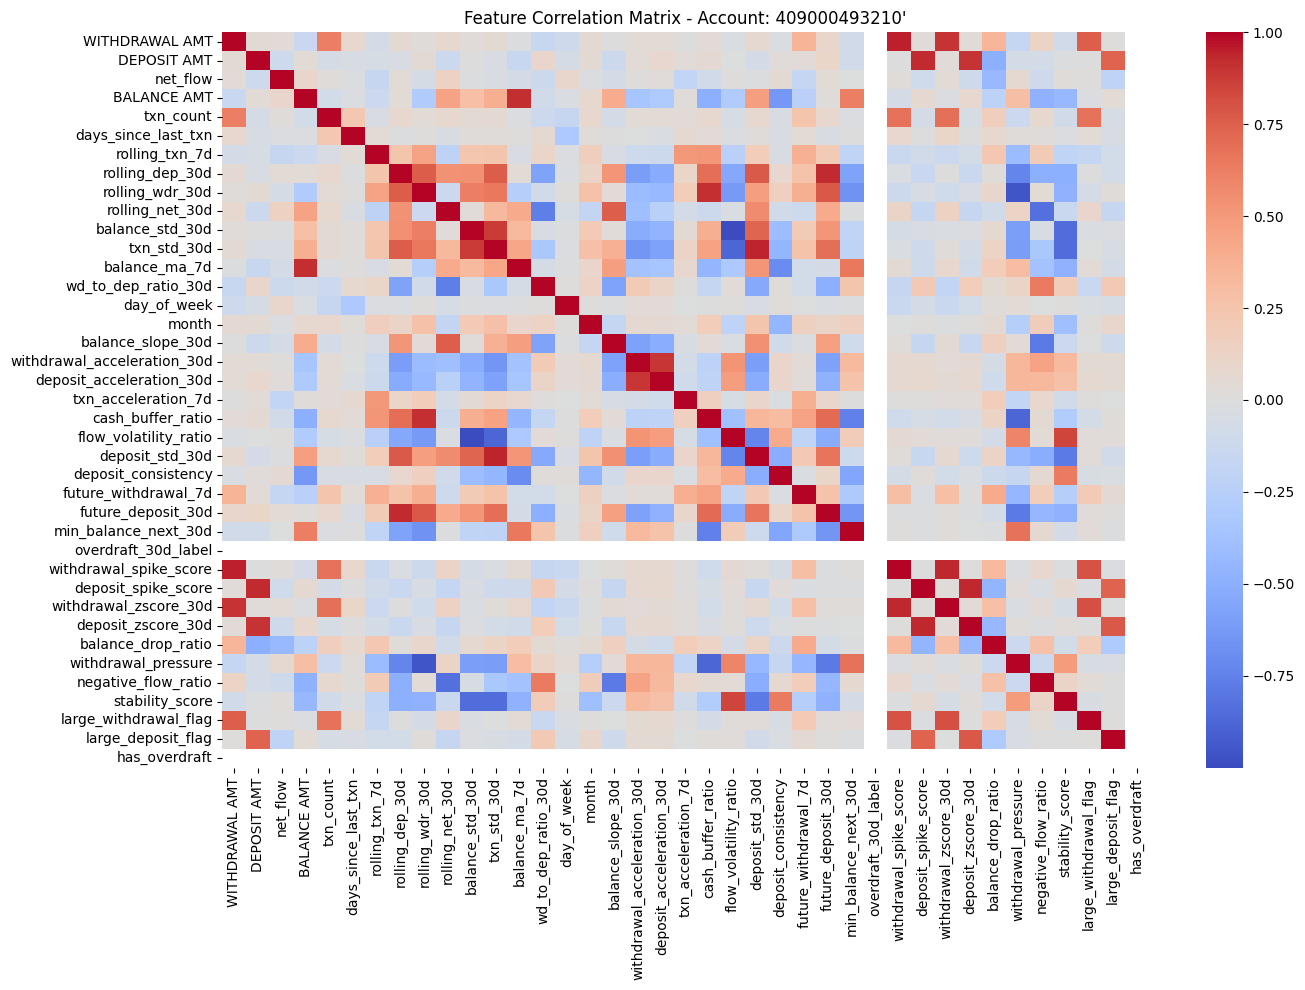

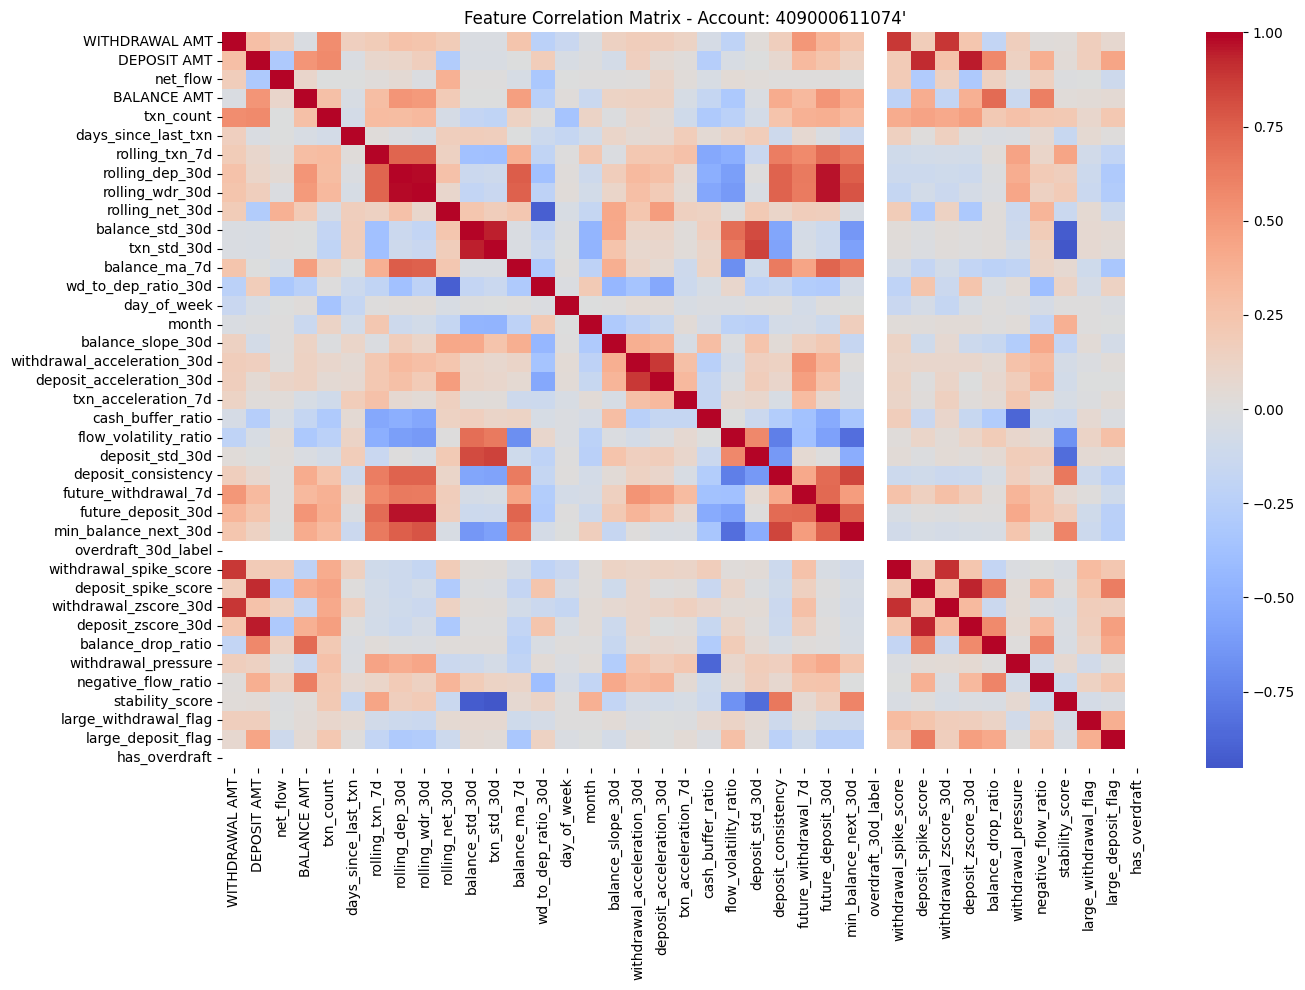

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt

def visualize_correlation_accountwise(data, account_col):

    numeric_cols = data.select_dtypes(include='number')

    for account in data[account_col].unique():

        account_data = data[data[account_col] == account]
        numeric_account = account_data[numeric_cols.columns]

        if len(numeric_account) > 1:  # Avoid errors for very small accounts

            plt.figure(figsize=(14,10))
            sns.heatmap(numeric_account.corr(),
                        cmap='coolwarm',
                        center=0,
                        annot=False)

            plt.title(f"Feature Correlation Matrix - Account: {account}")
            plt.tight_layout()
            plt.show()
visualize_correlation_accountwise(processed_df, 'Account No')

In [12]:
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt
import xgboost as xgb
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

def train_xgboost_account_time(
    df,
    features,
    target,
    task="regression",
    log_target=False,
    test_size=0.2,
    min_rows_per_account=20,
    model_path=None,
    random_state=42
):
    # logic strictly preserved from existing workflow
    df = df.sort_values(["Account No", "DATE"]).reset_index(drop=True)
    df = df.groupby("Account No").filter(lambda x: len(x) >= min_rows_per_account)

    if len(df) == 0:
        raise ValueError("No accounts left after filtering.")

    X = df[features].copy()
    y = df[target].copy()

    if task == "regression":
        upper_clip = y.quantile(0.995)
        y = y.clip(lower=0, upper=upper_clip)
        if log_target:
            y = np.log1p(y)

    train_idx, test_idx = [], []
    for acc, grp in df.groupby("Account No"):
        split = int(len(grp) * (1 - test_size))
        train_idx.extend(grp.index[:split])
        test_idx.extend(grp.index[split:])

    X_train, X_test = X.loc[train_idx], X.loc[test_idx]
    y_train, y_test = y.loc[train_idx], y.loc[test_idx]

    # Manual steps consolidated into Sklearn Pipeline to freeze logic and prevent leakage
    if task == "regression":
        estimator = xgb.XGBRegressor(
            n_estimators=1500, learning_rate=0.02, max_depth=4,
            subsample=0.8, colsample_bytree=0.8, reg_alpha=1.0,
            reg_lambda=2.0, objective="reg:squarederror",
            eval_metric="rmse", random_state=random_state, n_jobs=-1
        )
    else:
        estimator = xgb.XGBClassifier(
            n_estimators=1000, learning_rate=0.02, max_depth=4,
            subsample=0.8, colsample_bytree=0.8, reg_alpha=1.0,
            reg_lambda=2.0, objective="binary:logistic",
            eval_metric="auc", random_state=random_state, n_jobs=-1
        )

    model_pipeline = Pipeline([
        ('imputer', SimpleImputer(strategy='constant', fill_value=0)),
        ('scaler', StandardScaler()),
        ('model', estimator)
    ])

    model_pipeline.fit(X_train, y_train)
    preds = model_pipeline.predict(X_test)

    results = {}
    if task == "regression":
        y_true = np.expm1(y_test) if log_target else y_test
        y_pred = np.expm1(preds) if log_target else preds
        results.update({"RMSE": np.sqrt(mean_squared_error(y_true, y_pred)), "MAE": mean_absolute_error(y_true, y_pred), "R2": r2_score(y_true, y_pred)})
        print(f"R2 Score: {results['R2']}")

    if model_path:
        joblib.dump({"pipeline": model_pipeline, "features": features, "log_target": log_target}, model_path)

    return model_pipeline, results, X_test

In [13]:
def predict_future(raw_df, pipeline_dict):
    """
    Strict inference function that applies existing cleaning/features and the frozen pipeline.
    """
    pipe = pipeline_dict['pipeline']
    feats = pipeline_dict['features']
    use_log = pipeline_dict['log_target']

    # Apply strictly prohibited-to-change manual logic
    cleaned = dataCleaning(raw_df)
    processed = featureCreation(cleaned)

    # Manual shift to match training state
    for col in feats:
        processed[col] = processed.groupby("Account No")[col].shift(1)

    data_for_pred = processed.dropna(subset=feats)
    X = data_for_pred[feats]

    preds = pipe.predict(X)
    return np.expm1(preds) if use_log else preds

In [14]:
features = [
    # Withdrawal behavior
    "WITHDRAWAL AMT",
    "rolling_wdr_30d",
    "withdrawal_zscore_30d",
    "withdrawal_pressure",
    # Balance & liquidity
    "BALANCE AMT",
    "balance_ma_7d",
    "balance_std_30d",
    "cash_buffer_ratio",
    "negative_flow_ratio",
    # Flow dynamics
    "net_flow",
    "rolling_net_30d",
    "wd_to_dep_ratio_30d",
    "DEPOSIT AMT",
    # Volatility & stability
    "flow_volatility_ratio",
    "balance_slope_30d",
    # Activity & time
    "txn_count",
    "days_since_last_txn"
]

# Note: model variable now holds the full scikit-learn Pipeline object
model_pipeline, results, X_test = train_xgboost_account_time(
    df=processed_df,
    features=features,
    target="future_withdrawal_7d",
    task="regression",
    log_target=True,
    min_rows_per_account=20,
    model_path="future_withdrawal_pipeline.pkl"
)

print("Training Results:", results)

# Example of using the inference function:
import joblib
pipeline_dict = joblib.load("future_withdrawal_pipeline.pkl")
# predictions = predict_future(df, pipeline_dict)
# print(predictions[:5])

R2 Score: 0.793006726513978
Training Results: {'RMSE': np.float64(51282140.98192078), 'MAE': 19143060.332875215, 'R2': 0.793006726513978}


In [15]:
display(processed_df["future_withdrawal_7d"].describe())
processed_df["future_withdrawal_7d"].min()


count    5.848000e+03
mean     2.754392e+08
std      3.920619e+08
min      0.000000e+00
25%      3.496336e+06
50%      7.615464e+07
75%      3.952586e+08
max      1.823903e+09
Name: future_withdrawal_7d, dtype: float64

0.0

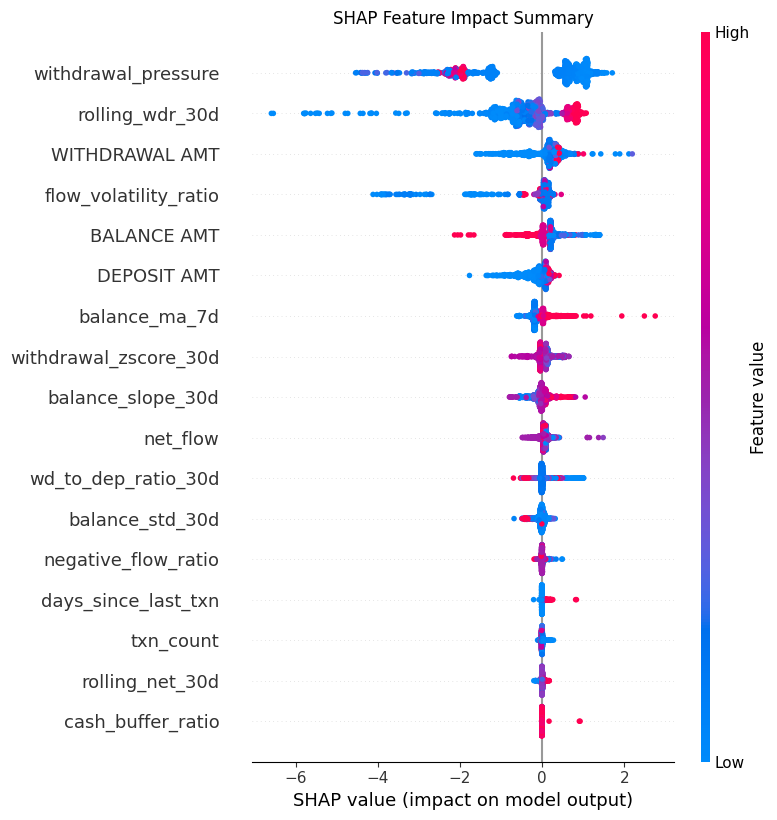

In [16]:
import shap
# Extract model from pipeline for SHAP
model_step = model_pipeline.named_steps['model']
# Transform X_test through imputer and scaler for SHAP compatibility
X_test_transformed = model_pipeline.named_steps['scaler'].transform(
    model_pipeline.named_steps['imputer'].transform(X_test)
)

explainer = shap.TreeExplainer(model_step)
shap_values = explainer.shap_values(X_test_transformed)

# Summary plot of feature impact
plt.title("SHAP Feature Impact Summary")
shap.summary_plot(shap_values, X_test_transformed, feature_names=features)